# Farm use case LLM scalability

In [ ]:
%cd ..

In [ ]:
%pwd  # should be "llm-adaptation"

## Run the experiment

In [73]:
import subprocess

def run(llm_config, scale_config, variant_conf):
    configs = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/scalability/scale.yaml", "configs/jinja.yaml", "DSL/drones.yaml", f"configs/{llm_config}.yaml", "farm/configs/no_battery_llm.yaml", "farm/configs/simulation_description_2.yaml"] + variant_conf + ["configs/retry2.yaml", f"farm/configs/scalability/{scale_config}.yaml"]  # without strategy
    run = ["python", "main.py", *configs, "-e", "1", "-s", "1"]

    print(" ".join(run))
    return  # remove this line to actually run the experiment using subprocess (this will only output the run parameters)

    # result = subprocess.run(run, capture_output=False)
    result = subprocess.run(run, capture_output=True)
    stdout = result.stdout.decode("utf-8")
    print(stdout.partition("Simulation done")[2])

    stderr = result.stderr.decode("utf-8")
    if (stderr):
        print(stderr)

### GPT-4o mini

In [78]:
import itertools

params_gpt4omini = {
    "scale": ["scale1", "scale3", "scale10", "scale20", "scale57", "scale116"],
    "variant": [[], ["farm/configs/step_by_step_multiple.yaml"], ["farm/configs/strategy_multiple.yaml"], ["farm/configs/strategy_multiple.yaml", "configs/ensemble_first_component_retry.yaml"]]
}
grid_gpt4omini = list(itertools.product(*params_gpt4omini.values()))
print(len(grid_gpt4omini))

24


In [74]:
for scale, variant in grid_gpt4omini:
    run("llm_gpt4omini", scale, variant)

python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/step_by_step_multiple.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/strategy_multiple.yaml configs/retry2.yaml farm/configs/scal

### o3-mini

In [76]:
params_o3mini = {
    "scale": ["scale1", "scale5", "scale17", "scale35", "scale90", "scale180"],
    "variant": [[], ["farm/configs/step_by_step_multiple.yaml"], ["farm/configs/strategy_multiple.yaml"]]
}
grid_o3mini = list(itertools.product(*params_o3mini.values()))
print(len(grid_o3mini))

18


In [77]:
for scale, variant in grid_o3mini:
    run("llm_o3mini", scale, variant)

python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/step_by_step_multiple.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/strategy_multiple.yaml configs/retry2.yaml farm/configs/scalability/s

## Results

### Load data

In [119]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statistics
sns.set_theme()

In [120]:
# results_folder = Path("./logs/no_battery/scale")
results_folder = Path("./results/scale")

In [121]:
results_files = sorted(results_folder.glob("*/*.llm.csv"))
print(len(results_files), "files found")

48 files found


In [122]:
datas = []

In [123]:
for file in results_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        data = pd.read_csv(file, low_memory=False)
        stats_file = file.parent / name.replace(".llm", ".csv")
        stats = pd.read_csv(stats_file, low_memory=False)
        damage = stats.iloc[299]["damage"]

        parts = name.split("_")
        llm = parts[1]
        scale = parts[-1].split(".")[0]
        params = parts[2:-1]
        params = ",\n".join(params)

        if "efcr" in params:
            variant = "ensemble-first"
        elif "strategy" in params:
            variant = "high"
        # elif "step-by-step" in params:
        elif "step-by-step" in params:
            if "V2" in params:
                variant = "low"
            else:
                continue
        else:
            variant = "zero"

        # Choose whether to use the variant or not in charts below
        # data["llm"] = llm
        data["llm"] = llm + "_" + variant

        data["llm_variant"] = llm + "_" + variant
        data["llm_only"] = llm
        data["scale"] = scale
        data["params"] = params
        data["damage"] = damage

        # counts of drones in state
        steps = stats[stats["step"].isin(data["step"])]
        data["protecting"] = np.nan
        data["idle"] = np.nan
        data["moving_to_field"] = np.nan
        mask = data["try"] == 0
        data.loc[mask, "protecting"] = steps["PROTECTING"].values
        data.loc[mask, "idle"] = steps["IDLE"].values
        data.loc[mask, "moving_to_field"] = steps["MOVING_TO_FIELD"].values

        datas.append(data)

    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

In [124]:
summary = pd.concat(datas, ignore_index=True)
summary

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,llm_variant,llm_only,scale,params,damage,protecting,idle,moving_to_field
0,1,0,0,1160,423,0,8.343977,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,0.0,4.0,4.0
1,11,0,0,1200,453,0,7.115220,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,2.0,2.0,4.0
2,21,0,0,1218,457,0,9.499124,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,4.0,1.0,3.0
3,31,0,0,1223,333,0,4.903902,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,7.0,0.0,1.0
4,41,0,0,1232,524,0,10.714981,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,6.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,251,1,0,52416,6403,2112,52.587189,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,NaN,NaN,NaN
1761,261,0,0,47824,6879,2624,50.481284,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0
1762,271,0,0,47848,6943,2688,48.294579,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0
1763,281,0,0,48054,5791,1536,47.294544,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,1.0,688.0,11.0


In [125]:
summary['original_scale'] = summary['scale'].apply(lambda s: int(s.split("scale")[-1]))
summary['original_scale_str'] = summary['scale']
summary['scale'] = summary['scale'].map({
    # gpt4omini
    "scale1": 1,
    "scale3": 2,
    "scale10": 5,
    "scale20": 10,
    "scale57": 25,
    "scale116": 50,
    # o3mini
    "scale5": 2,
    "scale17": 5,
    "scale35": 10,
    "scale90": 25,
    "scale180": 50,
})

In [126]:
summary.to_csv(results_folder / "summary.csv", index=False)

In [127]:
print("Ran experiments: table shows number of steps (should be 30)")
pivot = summary[summary["try"] == 0].pivot_table(values='step', index='llm', columns='scale', aggfunc='count', fill_value=0)
pivot

Ran experiments: table shows number of steps (should be 30)


scale,1,2,5,10,25,50
llm,,,,,,
gpt4omini_ensemble-first,30,30,30,30,30,30
gpt4omini_high,30,30,30,30,30,30
gpt4omini_low,30,30,30,30,30,30
gpt4omini_zero,30,30,30,30,30,30
o3mini_high,30,30,30,30,30,30
o3mini_low,30,30,30,30,30,30
o3mini_zero,30,30,30,30,30,30


### Process results

In [128]:
results = pd.DataFrame(columns=["llm_variant", "scale", "fields", "drones", "reasoning_tokens", "cost", "retry_rate", "second_retry_rate", "assigned_to_protection", "protecting", "response_time"])
for llm in summary["llm"].unique():
    for scale in sorted(summary["scale"].unique()):
        results.loc[len(results)] = pd.Series()
        results.loc[len(results)-1, "llm_variant"] = llm
        results.loc[len(results)-1, "scale"] = scale
results.set_index(["llm_variant", "scale"], inplace=True)
results

fields drones reasoning_tokens cost retry_rate  \
llm_variant              scale                                                  
gpt4omini_zero           1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   
gpt4omini_low            1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   
gpt4omini_high           1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   
gpt4omini_ensemble-first 1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   
o3mini_zero              1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   
o3mini_low               1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   
o3mini_high              1        NaN    NaN              NaN  NaN        NaN   
                         2        NaN    NaN              NaN  NaN        NaN   
                         5        NaN    NaN              NaN  NaN        NaN   
                         10       NaN    NaN              NaN  NaN        NaN   
                         25       NaN    NaN              NaN  NaN        NaN   
                         50       NaN    NaN              NaN  NaN        NaN   

                               second_retry_rate assigned_to_protection  \
llm_variant              scale                                            
gpt4omini_zero           1                   NaN                    NaN   
                         2                   NaN                    NaN   
                         5                   NaN                    NaN   
                         10                  NaN                    NaN   
                

In [129]:
for llm in summary["llm"].unique():
    if "gpt4omini" in llm:
        results.loc[(llm, 1), ["fields", "drones"]] = [4, 8]
        results.loc[(llm, 2), ["fields", "drones"]] = [12, 24]
        results.loc[(llm, 5), ["fields", "drones"]] = [40, 79]
        results.loc[(llm, 10), ["fields", "drones"]] = [80, 162]
        results.loc[(llm, 25), ["fields", "drones"]] = [228, 437]
        results.loc[(llm, 50), ["fields", "drones"]] = [464, 881]
    else:
        results.loc[(llm, 1), ["fields", "drones"]] = [4, 8]
        results.loc[(llm, 2), ["fields", "drones"]] = [20, 40]
        results.loc[(llm, 5), ["fields", "drones"]] = [68, 117]
        results.loc[(llm, 10), ["fields", "drones"]] = [140, 269]
        results.loc[(llm, 25), ["fields", "drones"]] = [360, 700]
        results.loc[(llm, 50), ["fields", "drones"]] = [720, 1388]
results

fields drones reasoning_tokens cost retry_rate  \
llm_variant              scale                                                  
gpt4omini_zero           1          4      8              NaN  NaN        NaN   
                         2         12     24              NaN  NaN        NaN   
                         5         40     79              NaN  NaN        NaN   
                         10        80    162              NaN  NaN        NaN   
                         25       228    437              NaN  NaN        NaN   
                         50       464    881              NaN  NaN        NaN   
gpt4omini_low            1          4      8              NaN  NaN        NaN   
                         2         12     24              NaN  NaN        NaN   
                         5         40     79              NaN  NaN        NaN   
                         10        80    162              NaN  NaN        NaN   
                         25       228    437              NaN  NaN        NaN   
                         50       464    881              NaN  NaN        NaN   
gpt4omini_high           1          4      8              NaN  NaN        NaN   
                         2         12     24              NaN  NaN        NaN   
                         5         40     79              NaN  NaN        NaN   
                         10        80    162              NaN  NaN        NaN   
                         25       228    437              NaN  NaN        NaN   
                         50       464    881              NaN  NaN        NaN   
gpt4omini_ensemble-first 1          4      8              NaN  NaN        NaN   
                         2         12     24              NaN  NaN        NaN   
                         5         40     79              NaN  NaN        NaN   
                         10        80    162              NaN  NaN        NaN   
                         25       228    437              NaN  NaN        NaN   
                         50       464    881              NaN  NaN        NaN   
o3mini_zero              1          4      8              NaN  NaN        NaN   
                         2         20     40              NaN  NaN        NaN   
                         5         68    117              NaN  NaN        NaN   
                         10       140    269              NaN  NaN        NaN   
                         25       360    700              NaN  NaN        NaN   
                         50       720   1388              NaN  NaN        NaN   
o3mini_low               1          4      8              NaN  NaN        NaN   
                         2         20     40              NaN  NaN        NaN   
                         5         68    117              NaN  NaN        NaN   
                         10       140    269              NaN  NaN        NaN   
                         25       360    700              NaN  NaN        NaN   
                         50       720   1388              NaN  NaN        NaN   
o3mini_high              1          4      8              NaN  NaN        NaN   
                         2         20     40              NaN  NaN        NaN   
                         5         68    117              NaN  NaN        NaN   
                         10       140    269              NaN  NaN        NaN   
                         25       360    700              NaN  NaN        NaN   
                         50       720   1388              NaN  NaN        NaN   

                               second_retry_rate assigned_to_protection  \
llm_variant              scale                                            
gpt4omini_zero           1                   NaN                    NaN   
                         2                   NaN                    NaN   
                         5                   NaN                    NaN   
                         10                  NaN                    NaN   
                

In [130]:
initial = summary[summary["try"] == 0].copy()
initial

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,llm_variant,llm_only,scale,params,damage,protecting,idle,moving_to_field,original_scale,original_scale_str
0,1,0,0,1160,423,0,8.343977,gpt4omini_zero,gpt4omini_zero,gpt4omini,1,"sd2,\nretry2",310,0.0,4.0,4.0,1,scale1
1,11,0,0,1200,453,0,7.115220,gpt4omini_zero,gpt4omini_zero,gpt4omini,1,"sd2,\nretry2",310,2.0,2.0,4.0,1,scale1
2,21,0,0,1218,457,0,9.499124,gpt4omini_zero,gpt4omini_zero,gpt4omini,1,"sd2,\nretry2",310,4.0,1.0,3.0,1,scale1
3,31,0,0,1223,333,0,4.903902,gpt4omini_zero,gpt4omini_zero,gpt4omini,1,"sd2,\nretry2",310,7.0,0.0,1.0,1,scale1
4,41,0,0,1232,524,0,10.714981,gpt4omini_zero,gpt4omini_zero,gpt4omini,1,"sd2,\nretry2",310,6.0,1.0,1.0,1,scale1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,251,0,1,47817,8489,3968,60.096638,o3mini_high,o3mini_high,o3mini,25,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,676.0,24.0,90,scale90
1761,261,0,0,47824,6879,2624,50.481284,o3mini_high,o3mini_high,o3mini,25,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0,90,scale90
1762,271,0,0,47848,6943,2688,48.294579,o3mini_high,o3mini_high,o3mini,25,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0,90,scale90
1763,281,0,0,48054,5791,1536,47.294544,o3mini_high,o3mini_high,o3mini,25,"sd2,\nstrategyMultiple,\nretry2",7784,1.0,688.0,11.0,90,scale90


### Errors

In [131]:
repeated = pd.DataFrame(columns=["llm", "scale", "try", "error_count", "error_rate"])
for llm in summary["llm"].unique():
    for scale in summary["scale"].unique():
        for retry in (1, 2):
            count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == retry)])
            initial_count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == 0)])
            if initial_count > 0:
                repeated.loc[len(repeated)] = [llm, scale, retry, count, count / initial_count]
# repeated["error_rate"] = repeated["error_count"] / 30.0
repeated.sort_values(["llm", "scale", "try"], inplace=True)
repeated

,llm,scale,try,error_count,error_rate
36,gpt4omini_ensemble-first,1,1,13,0.433333
37,gpt4omini_ensemble-first,1,2,8,0.266667
44,gpt4omini_ensemble-first,2,1,23,0.766667
45,gpt4omini_ensemble-first,2,2,7,0.233333
38,gpt4omini_ensemble-first,5,1,30,1.000000
...,...,...,...,...,...
55,o3mini_zero,10,2,0,0.000000
58,o3mini_zero,25,1,2,0.066667
59,o3mini_zero,25,2,0,0.000000
52,o3mini_zero,50,1,2,0.066667


In [132]:
repeated[repeated["try"] == 1]

,llm,scale,try,error_count,error_rate
36,gpt4omini_ensemble-first,1,1,13,0.433333
44,gpt4omini_ensemble-first,2,1,23,0.766667
38,gpt4omini_ensemble-first,5,1,30,1.000000
42,gpt4omini_ensemble-first,10,1,30,1.000000
46,gpt4omini_ensemble-first,25,1,27,0.900000
40,gpt4omini_ensemble-first,50,1,25,0.833333
24,gpt4omini_high,1,1,0,0.000000
32,gpt4omini_high,2,1,0,0.000000
26,gpt4omini_high,5,1,2,0.066667
30,gpt4omini_high,10,1,6,0.200000


In [133]:
print("Retry rate")
for _, row in repeated[repeated["try"] == 1].iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['error_rate']:.1%}")
    results.loc[(row['llm'], row['scale']), "retry_rate"] = f"{row['error_rate']:.0%}"

Retry rate
gpt4omini_ensemble-first, 1: 43.3%
gpt4omini_ensemble-first, 2: 76.7%
gpt4omini_ensemble-first, 5: 100.0%
gpt4omini_ensemble-first, 10: 100.0%
gpt4omini_ensemble-first, 25: 90.0%
gpt4omini_ensemble-first, 50: 83.3%
gpt4omini_high, 1: 0.0%
gpt4omini_high, 2: 0.0%
gpt4omini_high, 5: 6.7%
gpt4omini_high, 10: 20.0%
gpt4omini_high, 25: 46.7%
gpt4omini_high, 50: 70.0%
gpt4omini_low, 1: 0.0%
gpt4omini_low, 2: 6.7%
gpt4omini_low, 5: 36.7%
gpt4omini_low, 10: 16.7%
gpt4omini_low, 25: 66.7%
gpt4omini_low, 50: 86.7%
gpt4omini_zero, 1: 0.0%
gpt4omini_zero, 2: 0.0%
gpt4omini_zero, 5: 3.3%
gpt4omini_zero, 10: 6.7%
gpt4omini_zero, 25: 60.0%
gpt4omini_zero, 50: 73.3%
o3mini_high, 1: 0.0%
o3mini_high, 2: 0.0%
o3mini_high, 5: 3.3%
o3mini_high, 10: 3.3%
o3mini_high, 25: 20.0%
o3mini_high, 50: 40.0%
o3mini_low, 1: 0.0%
o3mini_low, 2: 6.7%
o3mini_low, 5: 13.3%
o3mini_low, 10: 10.0%
o3mini_low, 25: 6.7%
o3mini_low, 50: 16.7%
o3mini_zero, 1: 0.0%
o3mini_zero, 2: 0.0%
o3mini_zero, 5: 6.7%
o3mini_zer

In [134]:
print("Second retry rate")
for _, row in repeated[repeated["try"] == 2].iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['error_rate']:.1%}")
    results.loc[(row['llm'], row['scale']), "second_retry_rate"] = f"{row['error_rate']:.0%}"

Second retry rate
gpt4omini_ensemble-first, 1: 26.7%
gpt4omini_ensemble-first, 2: 23.3%
gpt4omini_ensemble-first, 5: 40.0%
gpt4omini_ensemble-first, 10: 76.7%
gpt4omini_ensemble-first, 25: 66.7%
gpt4omini_ensemble-first, 50: 63.3%
gpt4omini_high, 1: 0.0%
gpt4omini_high, 2: 0.0%
gpt4omini_high, 5: 3.3%
gpt4omini_high, 10: 3.3%
gpt4omini_high, 25: 13.3%
gpt4omini_high, 50: 56.7%
gpt4omini_low, 1: 0.0%
gpt4omini_low, 2: 0.0%
gpt4omini_low, 5: 10.0%
gpt4omini_low, 10: 0.0%
gpt4omini_low, 25: 20.0%
gpt4omini_low, 50: 56.7%
gpt4omini_zero, 1: 0.0%
gpt4omini_zero, 2: 0.0%
gpt4omini_zero, 5: 0.0%
gpt4omini_zero, 10: 0.0%
gpt4omini_zero, 25: 13.3%
gpt4omini_zero, 50: 53.3%
o3mini_high, 1: 0.0%
o3mini_high, 2: 0.0%
o3mini_high, 5: 0.0%
o3mini_high, 10: 0.0%
o3mini_high, 25: 0.0%
o3mini_high, 50: 10.0%
o3mini_low, 1: 0.0%
o3mini_low, 2: 0.0%
o3mini_low, 5: 0.0%
o3mini_low, 10: 0.0%
o3mini_low, 25: 0.0%
o3mini_low, 50: 6.7%
o3mini_zero, 1: 0.0%
o3mini_zero, 2: 0.0%
o3mini_zero, 5: 0.0%
o3mini_zero

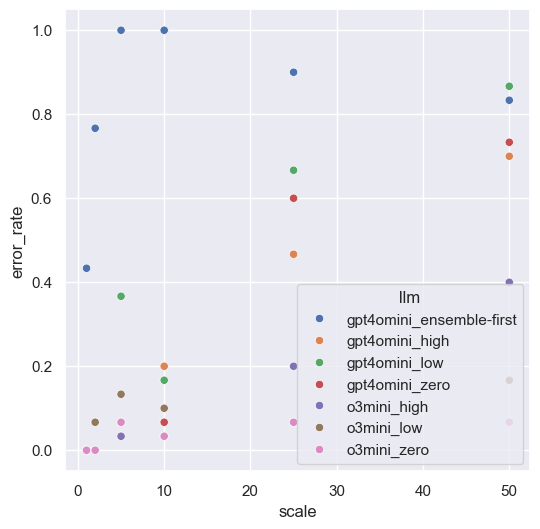

In [135]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="error_rate", hue="llm", data=repeated[repeated["try"] == 1], ax=ax, palette="deep")
plt.show()

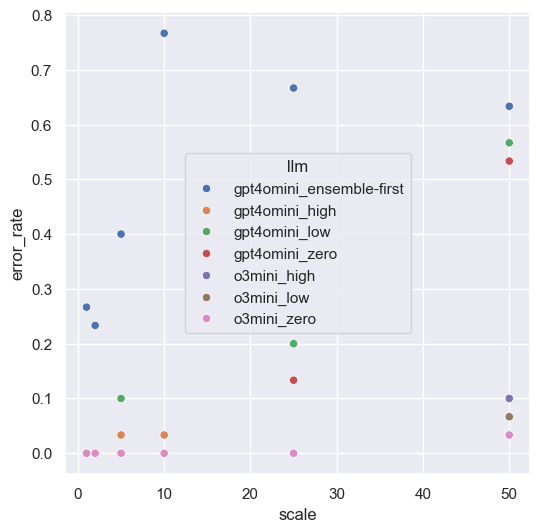

In [136]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="error_rate", hue="llm", data=repeated[repeated["try"] == 2], ax=ax, palette="deep")
plt.show()

### Time

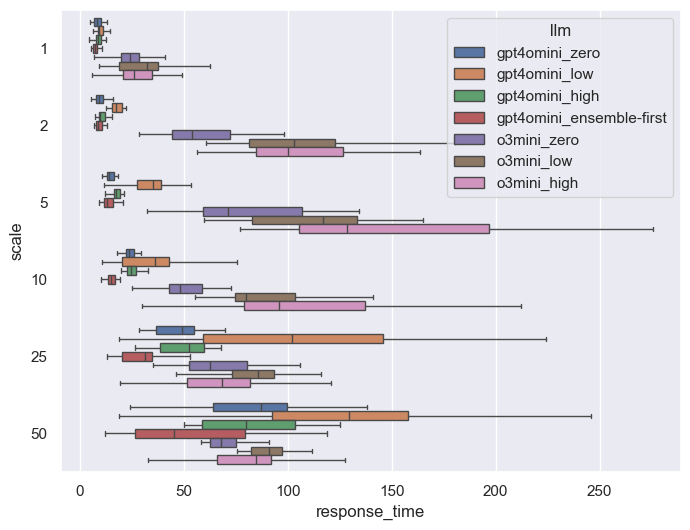

In [137]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="response_time", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

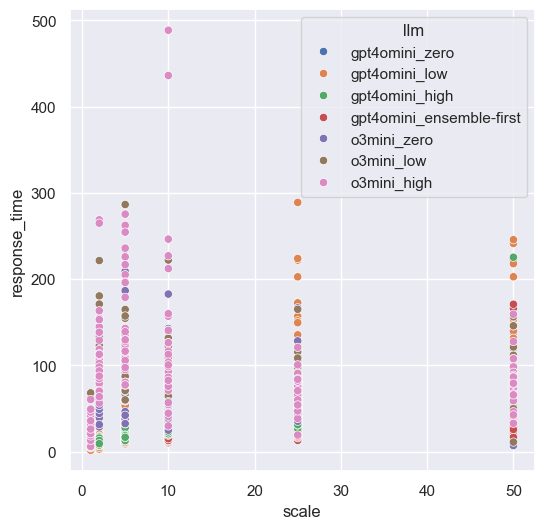

In [138]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Input tokens

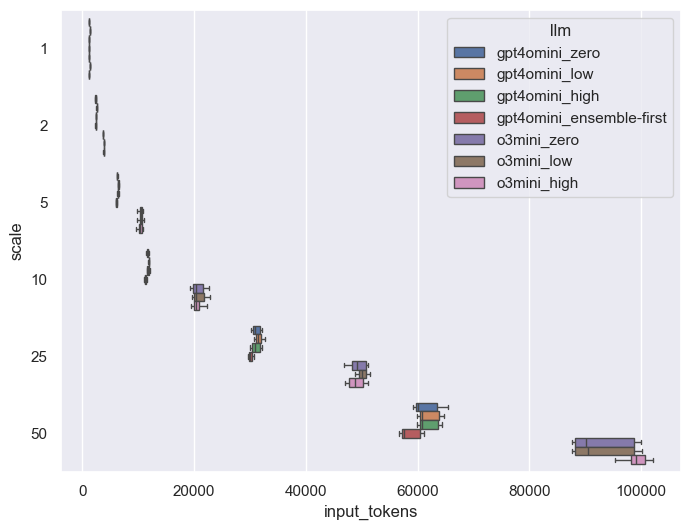

In [139]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="input_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

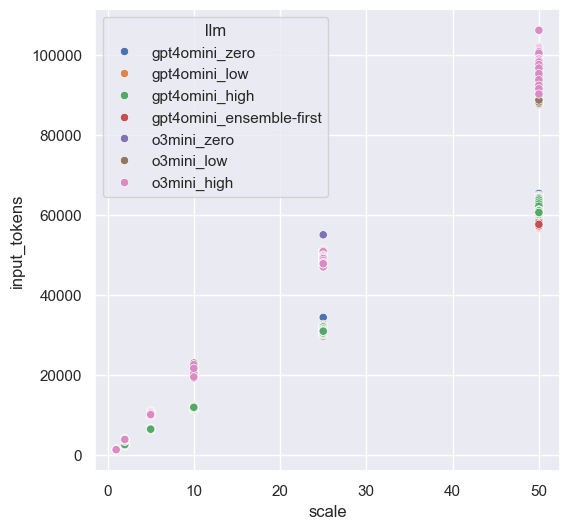

In [140]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="input_tokens", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

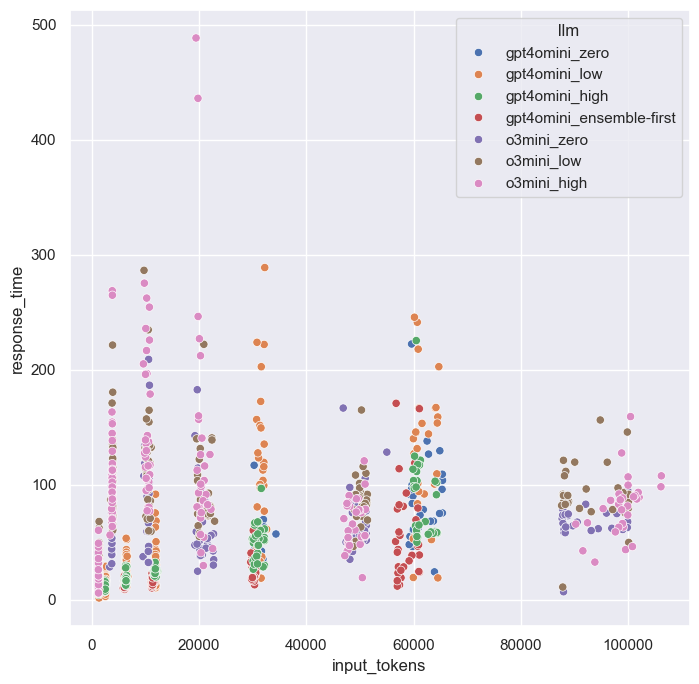

In [141]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="input_tokens", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Output tokens

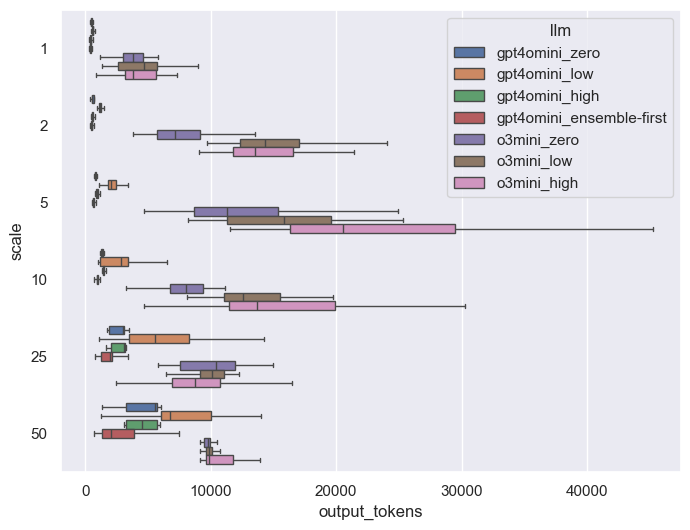

In [142]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="output_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

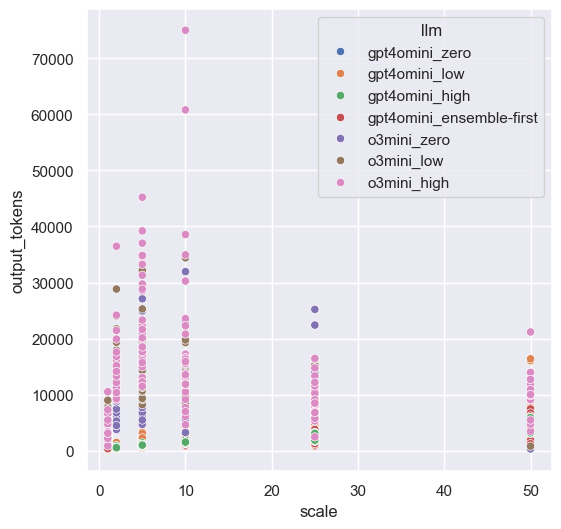

In [143]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="output_tokens", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

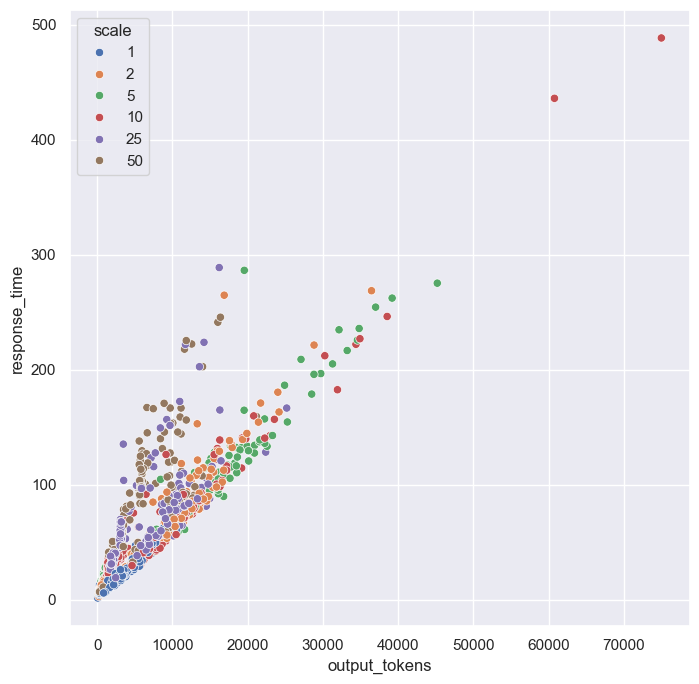

In [144]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

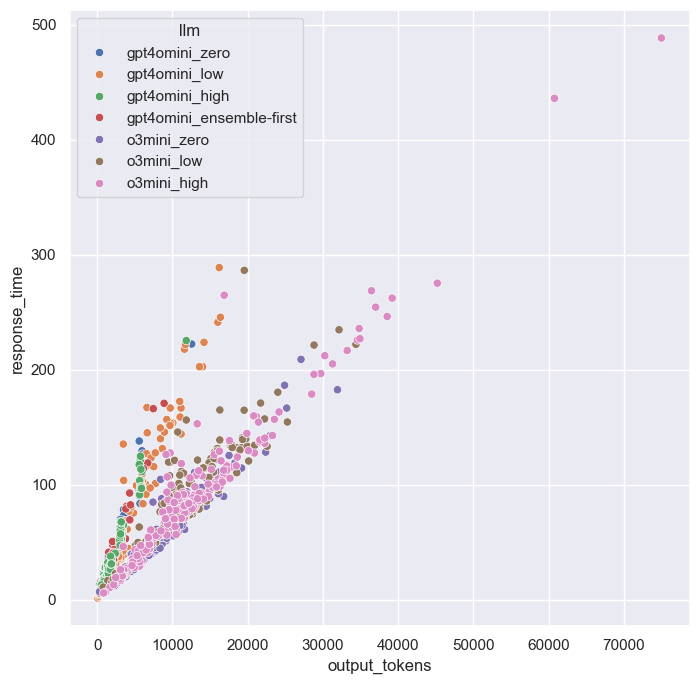

In [145]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Total tokens

In [146]:
initial["total_tokens"] = initial["input_tokens"] + initial["output_tokens"]

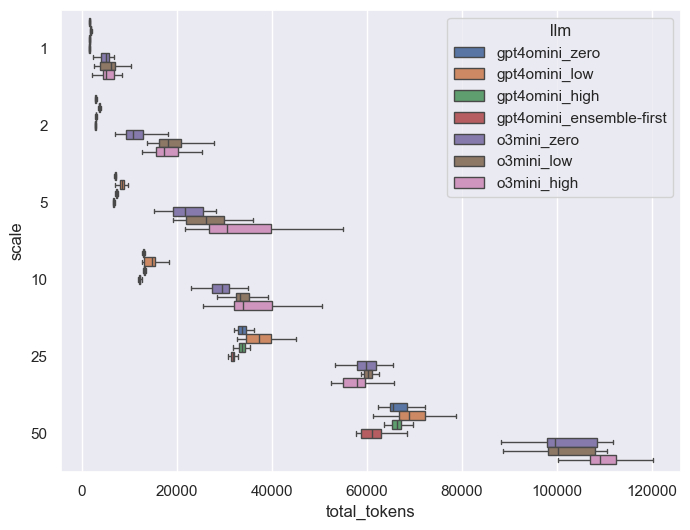

In [147]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="total_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

### Drone states

In [148]:
initial["assigned_to_protection"] = initial["protecting"] + initial["moving_to_field"]

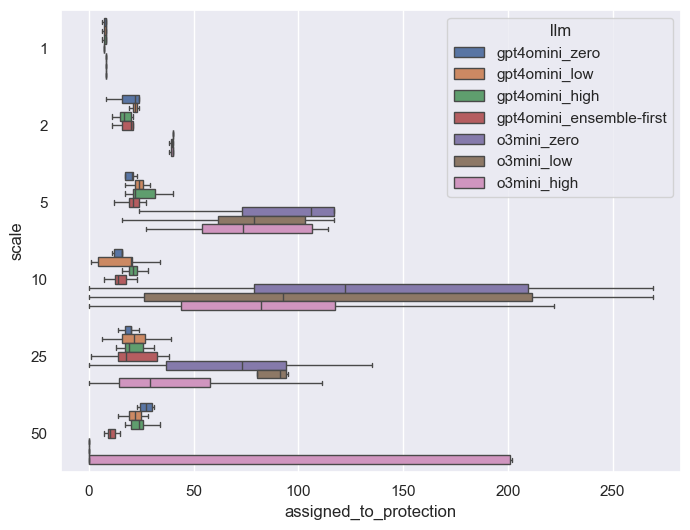

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="assigned_to_protection", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

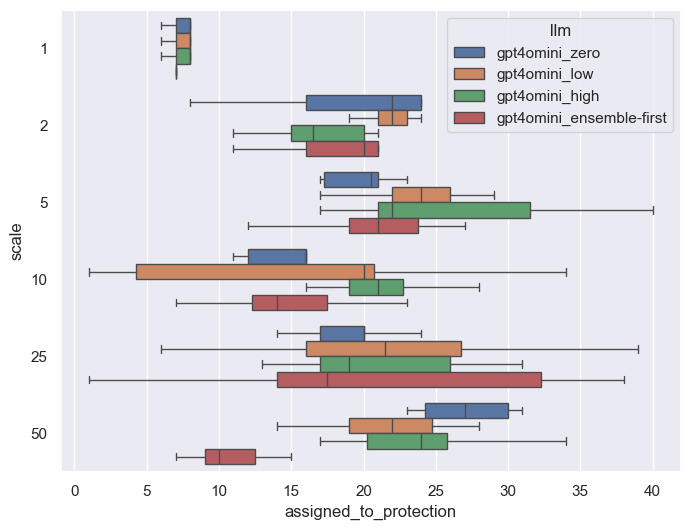

In [150]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="assigned_to_protection", y="scale", hue="llm", data=initial[initial["llm"].str.contains("gpt4omini")], ax=ax, orient="h", showfliers=False)
plt.show()

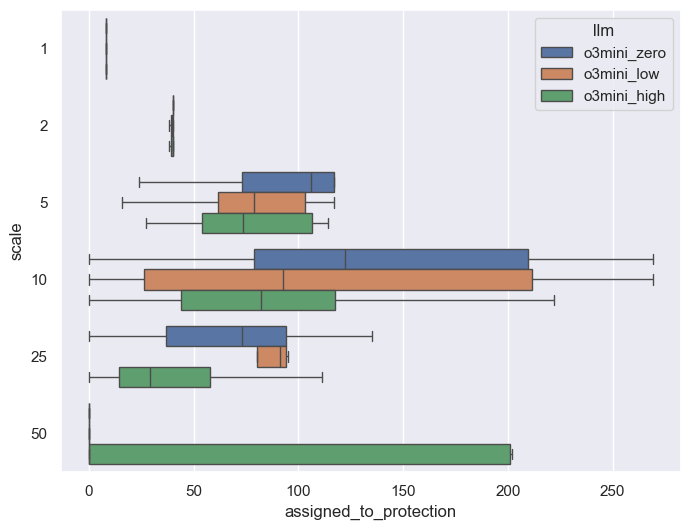

In [151]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="assigned_to_protection", y="scale", hue="llm", data=initial[initial["llm"].str.contains("o3mini")], ax=ax, orient="h", showfliers=False)
plt.show()

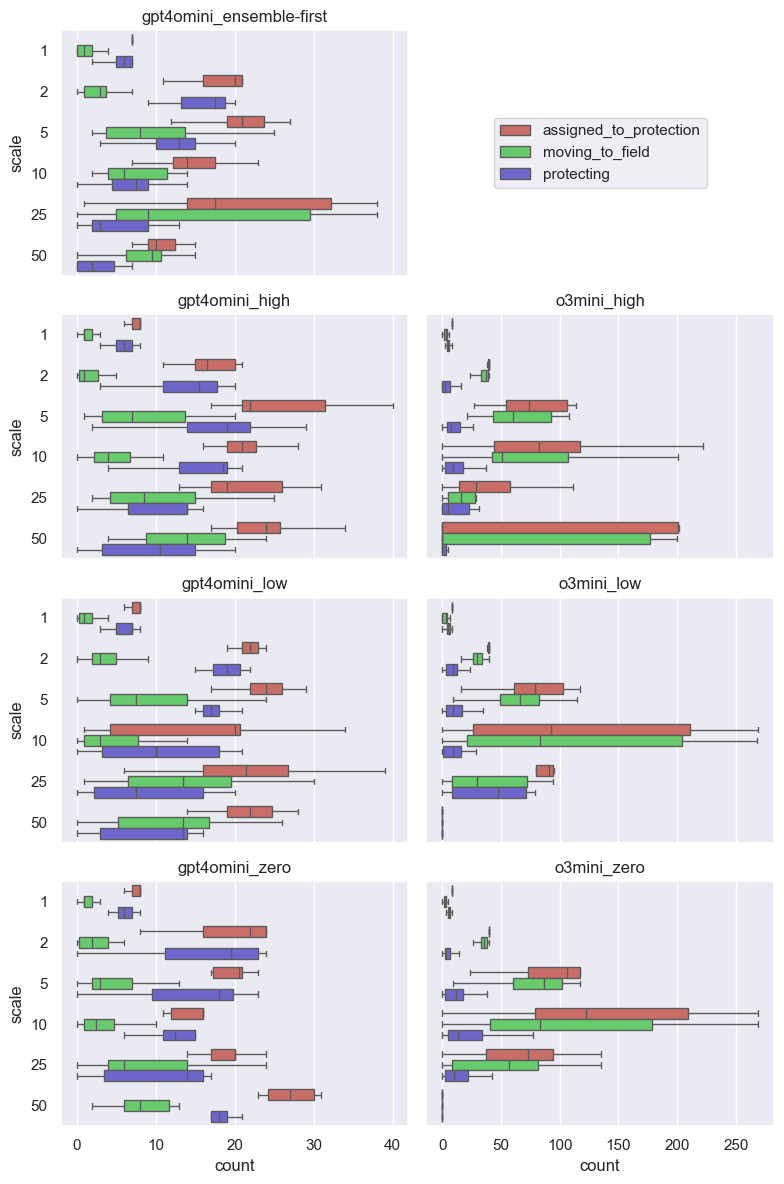

In [152]:
melted = pd.melt(
    initial,
    id_vars=["scale", "llm", "llm_variant", "llm_only"],
    value_vars=["assigned_to_protection", "moving_to_field", "protecting"],
    var_name="state",
    value_name="count"
)

fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex='col')
chart_data = list(melted.groupby("llm_variant"))
for i, ax in enumerate(axes.T.flatten()):
    if i == 4:
        continue
    if i > 4:
        i -= 1
    llm, group = chart_data[i]
    p = sns.boxplot(x="count", y="scale", hue="state", data=group, orient="h", ax=ax, showfliers=False, palette="hls", legend=i == 0)
    ax.set_title(llm)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        axes[0, 1].legend(handles, labels, loc="center")
        axes[0, 1].set_axis_off()
plt.tight_layout()
plt.show()


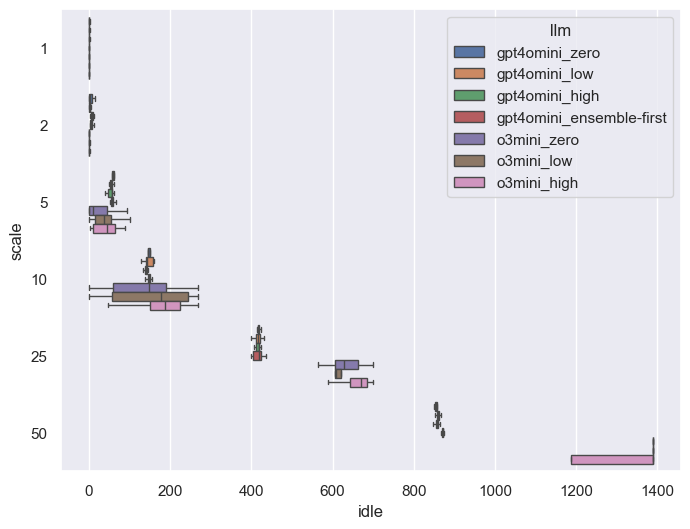

In [153]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="idle", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

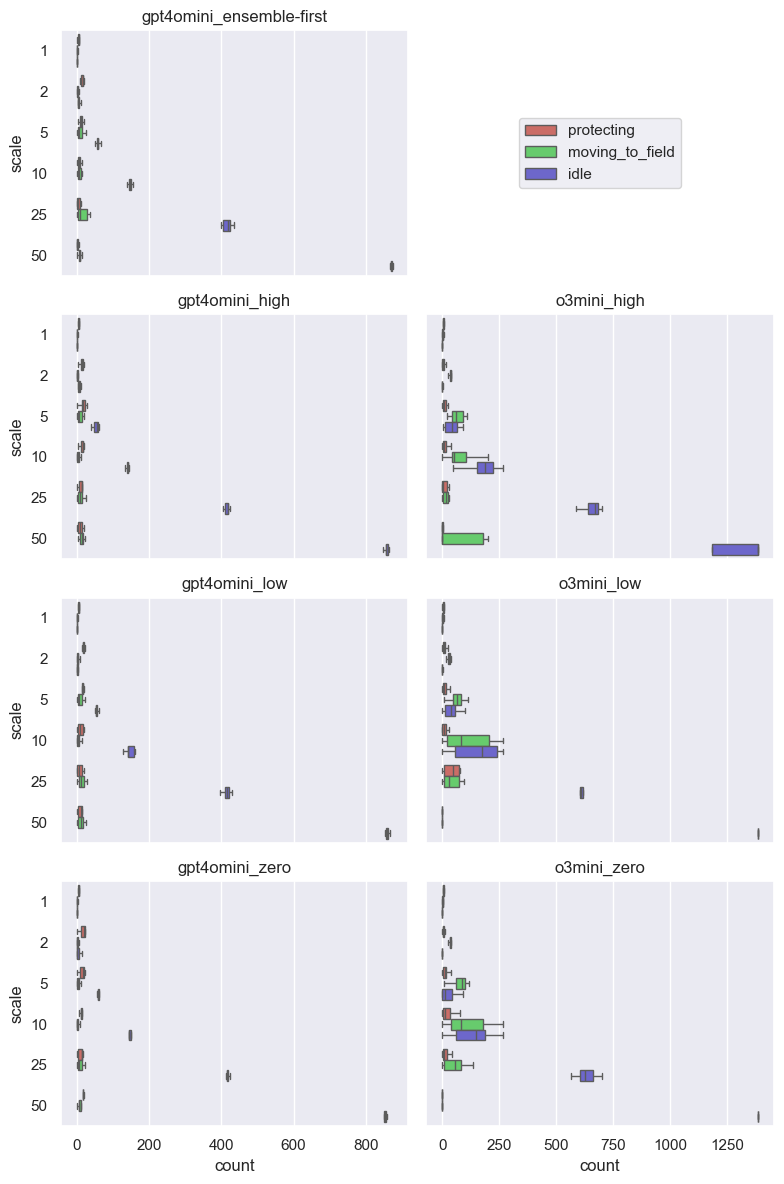

In [154]:
melted = pd.melt(
    initial,
    id_vars=["scale", "llm", "llm_variant"],
    value_vars=["protecting", "moving_to_field", "idle"],
    var_name="state",
    value_name="count"
)

fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex='col')
chart_data = list(melted.groupby("llm_variant"))
for i, ax in enumerate(axes.T.flatten()):
    if i == 4:
        continue
    if i > 4:
        i -= 1
    llm, group = chart_data[i]
    p = sns.boxplot(x="count", y="scale", hue="state", data=group, orient="h", ax=ax, showfliers=False, palette="hls", legend=i == 0)
    ax.set_title(llm)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        axes[0, 1].legend(handles, labels, loc="center")
        axes[0, 1].set_axis_off()
plt.tight_layout()
plt.show()

In [155]:
# states = initial.groupby(["llm", "scale"]).agg({"idle": "mean", "protecting": "mean", "moving_to_field": "mean"}).reset_index()
states = initial.groupby(["llm", "scale"]).agg({"idle": "median", "protecting": "median", "moving_to_field": "median", "assigned_to_protection": statistics.median_low}).reset_index()
states

,llm,scale,idle,protecting,moving_to_field,assigned_to_protection
0,gpt4omini_ensemble-first,1,1.0,6.0,1.0,7.0
1,gpt4omini_ensemble-first,2,4.0,17.5,3.0,20.0
2,gpt4omini_ensemble-first,5,58.0,13.0,8.0,21.0
3,gpt4omini_ensemble-first,10,148.0,7.5,6.0,14.0
4,gpt4omini_ensemble-first,25,419.5,3.0,9.0,17.0
5,gpt4omini_ensemble-first,50,871.0,2.0,9.5,10.0
6,gpt4omini_high,1,0.0,6.0,1.0,8.0
7,gpt4omini_high,2,7.5,15.5,1.0,16.0
8,gpt4omini_high,5,57.0,19.0,7.0,22.0
9,gpt4omini_high,10,141.0,18.5,4.0,21.0


In [156]:
for _, row in states.iterrows():
    results.loc[(row['llm'], row['scale']), "assigned_to_protection"] = f"{row['assigned_to_protection']:.0f} ({row['assigned_to_protection'] / results.loc[(row['llm'], row['scale']), 'drones']:.0%})"
    results.loc[(row['llm'], row['scale']), "protecting"] = f"{row['protecting']:.0f} ({row['protecting'] / results.loc[(row['llm'], row['scale']), 'drones']:.0%})"

### Damage

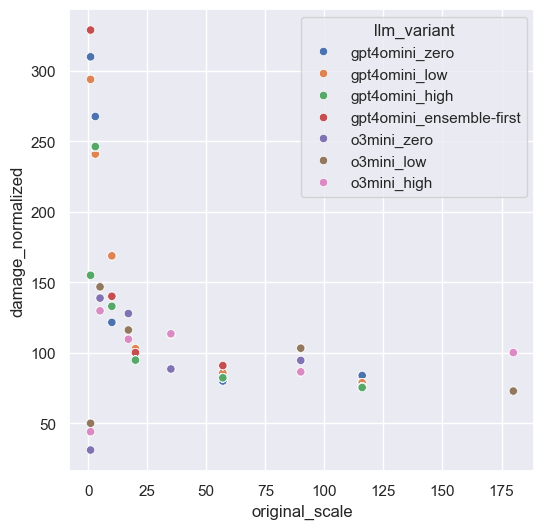

In [157]:
initial.loc[:,"damage_normalized"] = (initial["damage"] / initial["original_scale"])
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="original_scale", y="damage_normalized", hue="llm_variant", data=initial, ax=ax, palette="deep")
plt.show()

### Cost

In [158]:
initial.loc[:,"output_only_tokens"] = initial["output_tokens"] - initial["reasoning_tokens"]

In [159]:
averages = initial.groupby(["llm", "scale"]).agg({"input_tokens": "mean", "output_only_tokens": "mean", "reasoning_tokens": "mean", "response_time": "mean"}).reset_index()
averages

,llm,scale,input_tokens,output_only_tokens,reasoning_tokens,response_time
0,gpt4omini_ensemble-first,1,1274.466667,417.633333,0.000000,7.775766
1,gpt4omini_ensemble-first,2,2423.666667,520.933333,0.000000,9.471521
2,gpt4omini_ensemble-first,5,6122.166667,660.133333,0.000000,13.679626
3,gpt4omini_ensemble-first,10,11326.633333,962.466667,0.000000,15.558487
4,gpt4omini_ensemble-first,25,30136.666667,1791.733333,0.000000,30.075534
5,gpt4omini_ensemble-first,50,58538.500000,2890.100000,0.000000,57.695815
6,gpt4omini_high,1,1274.966667,424.700000,0.000000,8.975744
7,gpt4omini_high,2,2473.266667,577.333333,0.000000,10.794152
8,gpt4omini_high,5,6400.100000,964.433333,0.000000,18.325013
9,gpt4omini_high,10,11804.966667,1449.733333,0.000000,25.273116


In [160]:
prices = {
    "gpt4omini": { "input": 0.15 / 1_000_000, "output": 0.6 / 1_000_000, "reasoning": 0 },
    "o3mini": { "input": 1.1 / 1_000_000, "output": 4.4 / 1_000_000, "reasoning": 4.4 / 1_000_000 },
}
for llm in initial["llm_variant"].unique():
    if llm in prices: continue
    llm_only = llm.split("_")[0]
    prices[llm] = prices[llm_only]

In [161]:
averages["input_cost"] = averages["input_tokens"] * averages["llm"].map(lambda llm: prices[llm]["input"])
averages["output_cost"] = averages["output_only_tokens"] * averages["llm"].map(lambda llm: prices[llm]["output"])
averages["reasoning_cost"] = averages["reasoning_tokens"] * averages["llm"].map(lambda llm: prices[llm]["reasoning"])

In [162]:
averages

,llm,scale,input_tokens,output_only_tokens,reasoning_tokens,response_time,input_cost,output_cost,reasoning_cost
0,gpt4omini_ensemble-first,1,1274.466667,417.633333,0.000000,7.775766,0.000191,0.000251,0.000000
1,gpt4omini_ensemble-first,2,2423.666667,520.933333,0.000000,9.471521,0.000364,0.000313,0.000000
2,gpt4omini_ensemble-first,5,6122.166667,660.133333,0.000000,13.679626,0.000918,0.000396,0.000000
3,gpt4omini_ensemble-first,10,11326.633333,962.466667,0.000000,15.558487,0.001699,0.000577,0.000000
4,gpt4omini_ensemble-first,25,30136.666667,1791.733333,0.000000,30.075534,0.004521,0.001075,0.000000
5,gpt4omini_ensemble-first,50,58538.500000,2890.100000,0.000000,57.695815,0.008781,0.001734,0.000000
6,gpt4omini_high,1,1274.966667,424.700000,0.000000,8.975744,0.000191,0.000255,0.000000
7,gpt4omini_high,2,2473.266667,577.333333,0.000000,10.794152,0.000371,0.000346,0.000000
8,gpt4omini_high,5,6400.100000,964.433333,0.000000,18.325013,0.000960,0.000579,0.000000
9,gpt4omini_high,10,11804.966667,1449.733333,0.000000,25.273116,0.001771,0.000870,0.000000


In [163]:
for _, row in averages.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['input_cost']:.4f} + {row['output_cost']:.4f} + {row['reasoning_cost']:.4f}")

gpt4omini_ensemble-first, 1: 0.0002 + 0.0003 + 0.0000
gpt4omini_ensemble-first, 2: 0.0004 + 0.0003 + 0.0000
gpt4omini_ensemble-first, 5: 0.0009 + 0.0004 + 0.0000
gpt4omini_ensemble-first, 10: 0.0017 + 0.0006 + 0.0000
gpt4omini_ensemble-first, 25: 0.0045 + 0.0011 + 0.0000
gpt4omini_ensemble-first, 50: 0.0088 + 0.0017 + 0.0000
gpt4omini_high, 1: 0.0002 + 0.0003 + 0.0000
gpt4omini_high, 2: 0.0004 + 0.0003 + 0.0000
gpt4omini_high, 5: 0.0010 + 0.0006 + 0.0000
gpt4omini_high, 10: 0.0018 + 0.0009 + 0.0000
gpt4omini_high, 25: 0.0047 + 0.0017 + 0.0000
gpt4omini_high, 50: 0.0093 + 0.0028 + 0.0000
gpt4omini_low, 1: 0.0002 + 0.0003 + 0.0000
gpt4omini_low, 2: 0.0004 + 0.0007 + 0.0000
gpt4omini_low, 5: 0.0010 + 0.0013 + 0.0000
gpt4omini_low, 10: 0.0018 + 0.0016 + 0.0000
gpt4omini_low, 25: 0.0047 + 0.0038 + 0.0000
gpt4omini_low, 50: 0.0093 + 0.0047 + 0.0000
gpt4omini_zero, 1: 0.0002 + 0.0003 + 0.0000
gpt4omini_zero, 2: 0.0004 + 0.0003 + 0.0000
gpt4omini_zero, 5: 0.0009 + 0.0005 + 0.0000
gpt4omini_zer

In [164]:
group_col = "llm"
# group_col = "llm_variant"
totals = (
    initial
    .groupby([group_col, "scale"])
    .agg({
        "input_tokens": "sum",
        "output_only_tokens": "sum",
        "reasoning_tokens": "sum",
        "response_time": "mean",
        group_col: "size"  # counts rows per group
    })
    .rename(columns={group_col: "row_count"})
    .reset_index()
)
totals["input_cost"] = totals["input_tokens"] * totals[group_col].map(lambda llm: prices[llm]["input"])
totals["output_cost"] = totals["output_only_tokens"] * totals[group_col].map(lambda llm: prices[llm]["output"])
totals["reasoning_cost"] = totals["reasoning_tokens"] * totals[group_col].map(lambda llm: prices[llm]["reasoning"])

totals["input_cost"] /= (totals["row_count"] / 30)
totals["output_cost"] /= (totals["row_count"] / 30)
totals["reasoning_cost"] /= (totals["row_count"] / 30)

for _, row in totals.iterrows():
    print(f"{row[group_col]}, {row['scale']}: {row['input_cost'] + row['output_cost'] + row['reasoning_cost']:.2f}")
    results.loc[(row[group_col], row['scale']), "cost"] = f"{row['input_cost'] + row['output_cost'] + row['reasoning_cost']:.2f}"

gpt4omini_ensemble-first, 1: 0.01
gpt4omini_ensemble-first, 2: 0.02
gpt4omini_ensemble-first, 5: 0.04
gpt4omini_ensemble-first, 10: 0.07
gpt4omini_ensemble-first, 25: 0.17
gpt4omini_ensemble-first, 50: 0.32
gpt4omini_high, 1: 0.01
gpt4omini_high, 2: 0.02
gpt4omini_high, 5: 0.05
gpt4omini_high, 10: 0.08
gpt4omini_high, 25: 0.19
gpt4omini_high, 50: 0.36
gpt4omini_low, 1: 0.02
gpt4omini_low, 2: 0.03
gpt4omini_low, 5: 0.07
gpt4omini_low, 10: 0.10
gpt4omini_low, 25: 0.26
gpt4omini_low, 50: 0.42
gpt4omini_zero, 1: 0.01
gpt4omini_zero, 2: 0.02
gpt4omini_zero, 5: 0.04
gpt4omini_zero, 10: 0.08
gpt4omini_zero, 25: 0.19
gpt4omini_zero, 50: 0.36
o3mini_high, 1: 0.62
o3mini_high, 2: 2.09
o3mini_high, 5: 3.38
o3mini_high, 10: 3.20
o3mini_high, 25: 2.81
o3mini_high, 50: 4.63
o3mini_low, 1: 0.63
o3mini_low, 2: 2.14
o3mini_low, 5: 2.49
o3mini_low, 10: 2.48
o3mini_low, 25: 2.98
o3mini_low, 50: 4.32
o3mini_zero, 1: 0.55
o3mini_zero, 2: 1.14
o3mini_zero, 5: 1.95
o3mini_zero, 10: 1.97
o3mini_zero, 25: 3.08

In [165]:
for _, row in averages.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['response_time']:.1f}")
    results.loc[(row['llm'], row['scale']), "response_time"] = f"{row['response_time']:.1f}"

gpt4omini_ensemble-first, 1: 7.8
gpt4omini_ensemble-first, 2: 9.5
gpt4omini_ensemble-first, 5: 13.7
gpt4omini_ensemble-first, 10: 15.6
gpt4omini_ensemble-first, 25: 30.1
gpt4omini_ensemble-first, 50: 57.7
gpt4omini_high, 1: 9.0
gpt4omini_high, 2: 10.8
gpt4omini_high, 5: 18.3
gpt4omini_high, 10: 25.3
gpt4omini_high, 25: 50.8
gpt4omini_high, 50: 87.2
gpt4omini_low, 1: 9.7
gpt4omini_low, 2: 17.7
gpt4omini_low, 5: 33.3
gpt4omini_low, 10: 36.5
gpt4omini_low, 25: 111.6
gpt4omini_low, 50: 125.9
gpt4omini_zero, 1: 8.8
gpt4omini_zero, 2: 9.8
gpt4omini_zero, 5: 15.0
gpt4omini_zero, 10: 24.6
gpt4omini_zero, 25: 49.4
gpt4omini_zero, 50: 87.7
o3mini_high, 1: 27.7
o3mini_high, 2: 113.6
o3mini_high, 5: 148.9
o3mini_high, 10: 130.1
o3mini_high, 25: 67.7
o3mini_high, 50: 81.8
o3mini_low, 1: 31.4
o3mini_low, 2: 107.5
o3mini_low, 5: 118.4
o3mini_low, 10: 93.7
o3mini_low, 25: 85.6
o3mini_low, 50: 92.0
o3mini_zero, 1: 24.3
o3mini_zero, 2: 58.9
o3mini_zero, 5: 83.5
o3mini_zero, 10: 60.0
o3mini_zero, 25: 70.

### CoT tokens

In [166]:
import tiktoken
encoding = tiktoken.encoding_for_model("gpt-4o")

In [167]:
answer = len(encoding.encode("<answer>\n</answer>"))
answer

6

In [168]:
protecting = len(encoding.encode("Drone_123: protecting Field_456"))
protecting

8

In [169]:
idle = len(encoding.encode("Drone_123: idle"))
idle

5

In [170]:
initial.loc[:,"answer_tokens"] = answer + (initial["protecting"] + initial["moving_to_field"]) * protecting + initial["idle"] * idle

In [171]:
ansi_files = sorted(results_folder.glob("*/*.ansi"))
import re

for file in ansi_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        parts = name.split("_")
        llm = parts[1]
        scale = parts[-1].split(".")[0]
        params = parts[2:-1]
        params = ",\n".join(params)

        if "efcr" in params:
            variant = "ensemble-first"
        elif "strategy" in params:
            variant = "high"
        # elif "step-by-step" in params:
        elif "step-by-step" in params:
            if "V2" in params:
                variant = "low"
            else:
                continue
        else:
            variant = "zero"

        mask = (initial["llm"] == llm + "_" + variant) & (initial["original_scale_str"] == scale)

        log = file.read_text(encoding="utf-8")
        pattern = r"""

\[0m
\[36mRESPONSE:
(.*?)
\[0m
\[33mTOKENS USED:
.*?
\[0m"""
        matches = re.findall(pattern, log, re.DOTALL)
        answer_tokens_list = []
        for response in matches:
            answer_pattern = r"""<answer>.*?</answer>"""
            answer_match = re.findall(answer_pattern, response, re.DOTALL)
            answer_tokens_list.append(len(encoding.encode(answer_match[0])) if len(answer_match) > 0 else 0)

        initial.loc[mask,"answer_tokens"] = answer_tokens_list

    except Exception as e:
        print(file.stem, e)

In [172]:
initial[["llm", "errors", "answer_tokens", "output_only_tokens", "output_tokens"]]

,llm,errors,answer_tokens,output_only_tokens,output_tokens
0,gpt4omini_zero,0,66.0,423,423
1,gpt4omini_zero,0,72.0,453,453
2,gpt4omini_zero,0,75.0,457,457
3,gpt4omini_zero,0,78.0,333,333
4,gpt4omini_zero,0,75.0,524,524
...,...,...,...,...,...
1759,o3mini_high,1,4506.0,4521,8489
1761,o3mini_high,0,4242.0,4255,6879
1762,o3mini_high,0,4242.0,4255,6943
1763,o3mini_high,0,4242.0,4255,5791


In [173]:
initial.loc[:,"cot_tokens"] = initial["output_tokens"] - initial["answer_tokens"]
# no_errors = initial[initial["errors"] == 0]
no_errors = initial
for _, row in no_errors.groupby(["llm", "scale"]).agg({"cot_tokens": "mean"}).reset_index().iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['cot_tokens']:.0f}")
    results.loc[(row['llm'], row['scale']), "reasoning_tokens"] = f"{row['cot_tokens']:.0f}"  # TODO: Q1-Q3 instead of mean?

gpt4omini_ensemble-first, 1: 356
gpt4omini_ensemble-first, 2: 371
gpt4omini_ensemble-first, 5: 322
gpt4omini_ensemble-first, 10: 305
gpt4omini_ensemble-first, 25: 368
gpt4omini_ensemble-first, 50: 295
gpt4omini_high, 1: 349
gpt4omini_high, 2: 379
gpt4omini_high, 5: 407
gpt4omini_high, 10: 431
gpt4omini_high, 25: 584
gpt4omini_high, 50: 853
gpt4omini_low, 1: 477
gpt4omini_low, 2: 910
gpt4omini_low, 5: 1562
gpt4omini_low, 10: 1771
gpt4omini_low, 25: 4394
gpt4omini_low, 50: 4989
gpt4omini_zero, 1: 398
gpt4omini_zero, 2: 365
gpt4omini_zero, 5: 269
gpt4omini_zero, 10: 349
gpt4omini_zero, 25: 459
gpt4omini_zero, 50: 516
o3mini_high, 1: 4285
o3mini_high, 2: 14535
o3mini_high, 5: 22074
o3mini_high, 10: 17216
o3mini_high, 25: 4829
o3mini_high, 50: 2261
o3mini_low, 1: 4353
o3mini_low, 2: 14884
o3mini_low, 5: 15364
o3mini_low, 10: 11639
o3mini_low, 25: 5718
o3mini_low, 50: 1515
o3mini_zero, 1: 3798
o3mini_zero, 2: 7360
o3mini_zero, 5: 11166
o3mini_zero, 10: 7680
o3mini_zero, 25: 6654
o3mini_zero,

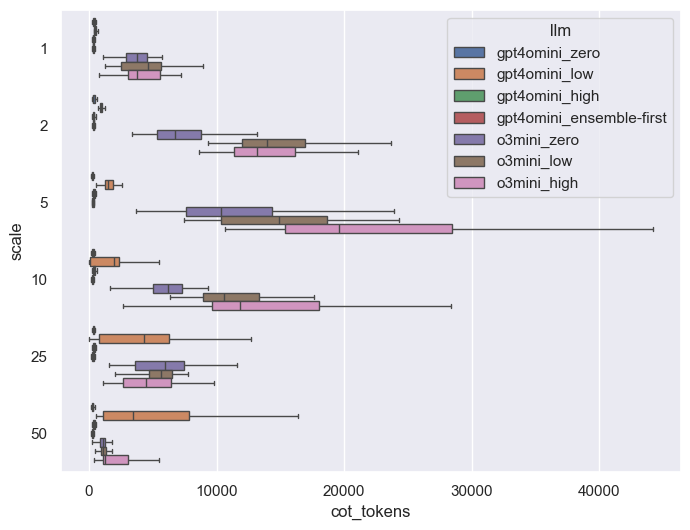

In [174]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="cot_tokens", y="scale", hue="llm", data=no_errors, ax=ax, orient="h", showfliers=False)
plt.show()

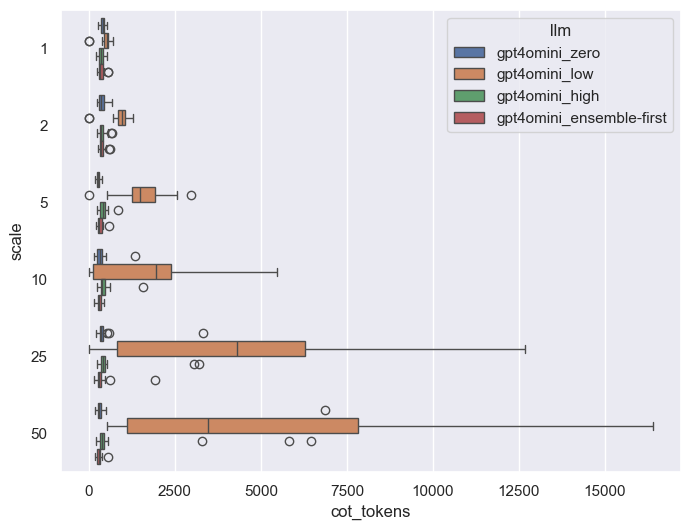

In [175]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="cot_tokens", y="scale", hue="llm", data=no_errors[no_errors["llm"].str.contains("gpt4omini")], ax=ax, orient="h", showfliers=True)
plt.show()

### Results table

In [176]:
results

fields drones reasoning_tokens  cost  \
llm_variant              scale                                        
gpt4omini_zero           1          4      8              398  0.01   
                         2         12     24              365  0.02   
                         5         40     79              269  0.04   
                         10        80    162              349  0.08   
                         25       228    437              459  0.19   
                         50       464    881              516  0.36   
gpt4omini_low            1          4      8              477  0.02   
                         2         12     24              910  0.03   
                         5         40     79             1562  0.07   
                         10        80    162             1771  0.10   
                         25       228    437             4394  0.26   
                         50       464    881             4989  0.42   
gpt4omini_high           1          4      8              349  0.01   
                         2         12     24              379  0.02   
                         5         40     79              407  0.05   
                         10        80    162              431  0.08   
                         25       228    437              584  0.19   
                         50       464    881              853  0.36   
gpt4omini_ensemble-first 1          4      8              356  0.01   
                         2         12     24              371  0.02   
                         5         40     79              322  0.04   
                         10        80    162              305  0.07   
                         25       228    437              368  0.17   
                         50       464    881              295  0.32   
o3mini_zero              1          4      8             3798  0.55   
                         2         20     40             7360  1.14   
                         5         68    117            11166  1.95   
                         10       140    269             7680  1.97   
                         25       360    700             6654  3.08   
                         50       720   1388             1099  4.32   
o3mini_low               1          4      8             4353  0.63   
                         2         20     40            14884  2.14   
                         5         68    117            15364  2.49   
                         10       140    269            11639  2.48   
                         25       360    700             5718  2.98   
                         50       720   1388             1515  4.32   
o3mini_high              1          4      8             4285  0.62   
                         2         20     40            14535  2.09   
                         5         68    117            22074  3.38   
                         10       140    269            17216  3.20   
                         25       360    700             4829  2.81   
                         50       720   1388             2261  4.63   

                               retry_rate second_retry_rate  \
llm_variant              scale                                
gpt4omini_zero           1             0%                0%   
                         2             0%                0%   
                         5             3%                0%   
                         10            7%                0%   
                         25           60%               13%   
                         50           73%               53%   
gpt4omini_low            1             0%                0%   
                         2             7%                0%   
                         5            37%               10%   
                         10           17%                0%   
                         25           67%               20%   
                         50           87%               57%   
gpt4omini_high          

In [177]:
results_table = results.reset_index()
results_table[['llm', 'variant']] = results_table['llm_variant'].str.split('_', n=1, expand=True)
results_table = results_table.drop("llm_variant", axis=1).set_index(['llm', 'variant'])


In [179]:
results_latex = []
last_llm = None
last_variant = None
for (llm, variant), row in results_table.iterrows():
    if pd.isna(row['drones']):  # skip rows without data
        continue

    data = f"{row['scale']}% & {row['fields']} & {row['drones']} & {row['reasoning_tokens']} & \\${row['cost']} & {row['retry_rate']} & {row['second_retry_rate']} & {row['assigned_to_protection']} & {row['protecting']} & {row['response_time']}"

    if last_llm != llm:
        results_latex.append("\\hline")
        llm_rowspan = len(results_table.loc[llm])
        variant_rowspan = len(results_table.loc[(llm, variant)])
        results_latex.append(
            f"\\multirow{{{llm_rowspan}}}{{*}}{{{llm}}} & \\multirow{{{variant_rowspan}}}{{*}}{{{variant}}} & {data} \\\\")
        last_llm = llm
        last_variant = variant
    elif last_variant != variant:
        results_latex.append("\\cline{2-12}")
        variant_rowspan = len(results_table.loc[(llm, variant)])
        results_latex.append(
            f"& \\multirow{{{variant_rowspan}}}{{*}}{{{variant}}} & {data} \\\\")
        last_variant = variant
    else:
        results_latex.append(
            f"& & {data} \\\\")

result_latex = "\n".join(results_latex)
result_latex = result_latex.replace("%", "\\%")
result_latex = result_latex.replace("gpt4omini", "\\rotatebox[origin=c]{90}{GPT-4o mini}")
result_latex = result_latex.replace("o3mini", "\\rotatebox[origin=c]{90}{o3-mini}")
result_latex = result_latex.replace("zero", "\\rotatebox[origin=c]{90}{Zero strategy}")
result_latex = result_latex.replace("high", "\\rotatebox[origin=c]{90}{High-level strategy}")
result_latex = result_latex.replace("low", "\\rotatebox[origin=c]{90}{Low-level strategy}")
result_latex = result_latex.replace("ensemble-first", "\\rotatebox[origin=c]{90}{Ensemble-first}")
print(result_latex)


\hline
\multirow{24}{*}{\rotatebox[origin=c]{90}{GPT-4o mini}} & \multirow{6}{*}{\rotatebox[origin=c]{90}{Zero strategy}} & 1\% & 4 & 8 & 398 & \$0.01 & 0\% & 0\% & 8 (100\%) & 6 (75\%) & 8.8 \\
& & 2\% & 12 & 24 & 365 & \$0.02 & 0\% & 0\% & 21 (88\%) & 20 (81\%) & 9.8 \\
& & 5\% & 40 & 79 & 269 & \$0.04 & 3\% & 0\% & 20 (25\%) & 18 (23\%) & 15.0 \\
& & 10\% & 80 & 162 & 349 & \$0.08 & 7\% & 0\% & 16 (10\%) & 12 (8\%) & 24.6 \\
& & 25\% & 228 & 437 & 459 & \$0.19 & 60\% & 13\% & 20 (5\%) & 14 (3\%) & 49.4 \\
& & 50\% & 464 & 881 & 516 & \$0.36 & 73\% & 53\% & 27 (3\%) & 18 (2\%) & 87.7 \\
\cline{2-12}
& \multirow{6}{*}{\rotatebox[origin=c]{90}{Low-level strategy}} & 1\% & 4 & 8 & 477 & \$0.02 & 0\% & 0\% & 8 (100\%) & 7 (88\%) & 9.7 \\
& & 2\% & 12 & 24 & 910 & \$0.03 & 7\% & 0\% & 22 (92\%) & 19 (79\%) & 17.7 \\
& & 5\% & 40 & 79 & 1562 & \$0.07 & 37\% & 10\% & 24 (30\%) & 17 (22\%) & 33.3 \\
& & 10\% & 80 & 162 & 1771 & \$0.10 & 17\% & 0\% & 20 (12\%) & 10 (6\%) & 36.5 \\
& & 25\% & 

C:\Users\micha\AppData\Local\Temp\ipykernel_21468\1368194525.py:13: PerformanceWarning: indexing past lexsort depth may impact performance.
  variant_rowspan = len(results_table.loc[(llm, variant)])
C:\Users\micha\AppData\Local\Temp\ipykernel_21468\1368194525.py:20: PerformanceWarning: indexing past lexsort depth may impact performance.
  variant_rowspan = len(results_table.loc[(llm, variant)])
